# Customer Churn Analysis

### Analyzing Customer Churn Patterns Using Python & Pandas

This project analyzes customer churn data to understand which customer groups are more likely to leave a service. The analysis explores factors such as contract type, tenure, monthly charges, internet service, and payment method.

**Tools Used:** Python, Pandas, Matplotlib, Jupyter Notebook

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Cleaning

The dataset was checked for missing values and incorrect data types. The `TotalCharges` column was stored as text, so it was converted to numeric values. Rows with missing `TotalCharges` values were then removed.

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])

print(df.shape)

## Overall Churn Analysis

This section looks at the overall distribution of customers who stayed with the service and those who left.

In [28]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)

churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


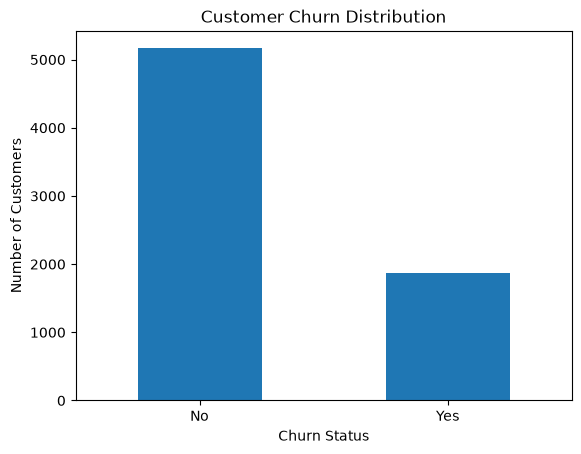

In [29]:
churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

## Churn Rate by Contract Type

This section compares customer churn across different contract types to identify differences in customer retention.

In [30]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn["Churn Rate (%)"] = (
    contract_churn["Yes"] /
    (contract_churn["Yes"] + contract_churn["No"])
) * 100

print(contract_churn)

Churn             No   Yes  Churn Rate (%)
Contract                                  
Month-to-month  2220  1655       42.709677
One year        1306   166       11.277174
Two year        1637    48        2.848665


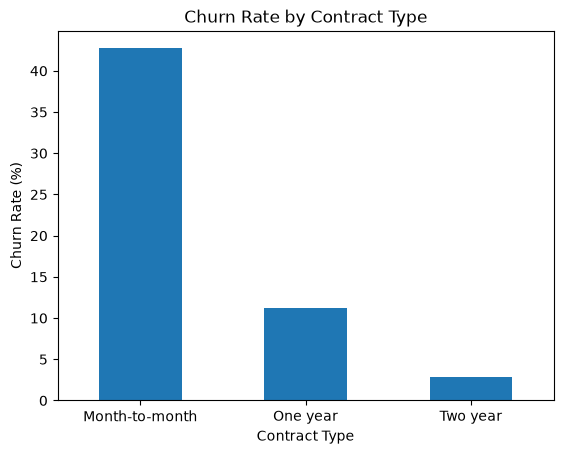

In [32]:
contract_churn["Churn Rate (%)"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Churn Rate by Customer Tenure

This section compares churn rates across different customer tenure groups to understand how customer retention changes over time.

In [33]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-60 months", "61-72 months"]
)

tenure_churn = df.groupby("TenureGroup", observed=True)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(tenure_churn)

TenureGroup
0-12 months     47.678161
13-24 months    28.710938
25-48 months    20.388959
49-60 months    14.423077
61-72 months     6.609808
Name: Churn, dtype: float64


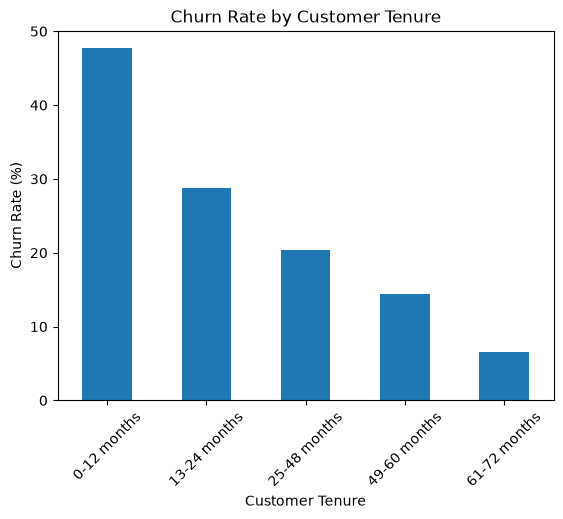

In [34]:
tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Average Monthly Charges by Churn Status

This section compares the average monthly charges of customers who stayed with the service and those who left.

In [35]:
monthly_charges = df.groupby("Churn")["MonthlyCharges"].mean()

print(monthly_charges)

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


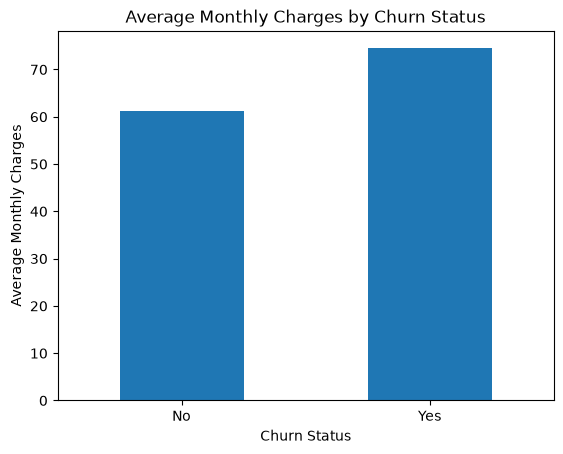

In [36]:
monthly_charges.plot(kind="bar")

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.show()

## Churn Rate by Internet Service

This section compares customer churn across different internet service types.

In [37]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

internet_churn["Churn Rate (%)"] = (
    internet_churn["Yes"] /
    (internet_churn["Yes"] + internet_churn["No"])
) * 100

print(internet_churn)

Churn              No   Yes  Churn Rate (%)
InternetService                            
DSL              1957   459       18.998344
Fiber optic      1799  1297       41.892765
No               1407   113        7.434211


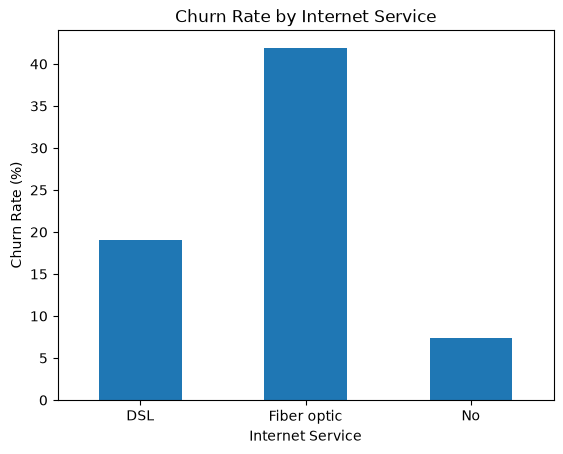

In [38]:
internet_churn["Churn Rate (%)"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Churn Rate by Payment Method

This section compares customer churn across different payment methods.

In [39]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"])

payment_churn["Churn Rate (%)"] = (
    payment_churn["Yes"] /
    (payment_churn["Yes"] + payment_churn["No"])
) * 100

print(payment_churn)

Churn                        No   Yes  Churn Rate (%)
PaymentMethod                                        
Bank transfer (automatic)  1284   258       16.731518
Credit card (automatic)    1289   232       15.253123
Electronic check           1294  1071       45.285412
Mailed check               1296   308       19.201995


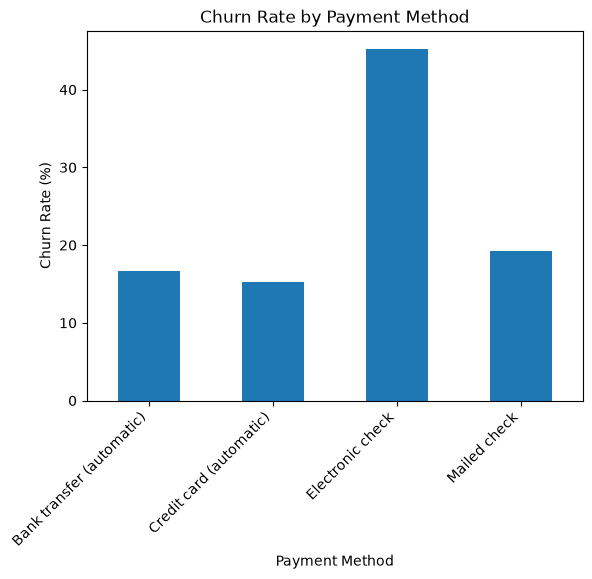

In [40]:
payment_churn["Churn Rate (%)"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Churn Rate by Senior Citizen Status

This section compares churn rates between senior and non-senior customers.

In [41]:
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"])

senior_churn["Churn Rate (%)"] = (
    senior_churn["Yes"] /
    (senior_churn["Yes"] + senior_churn["No"])
) * 100

print(senior_churn)

Churn            No   Yes  Churn Rate (%)
SeniorCitizen                            
0              4497  1393       23.650255
1               666   476       41.681261


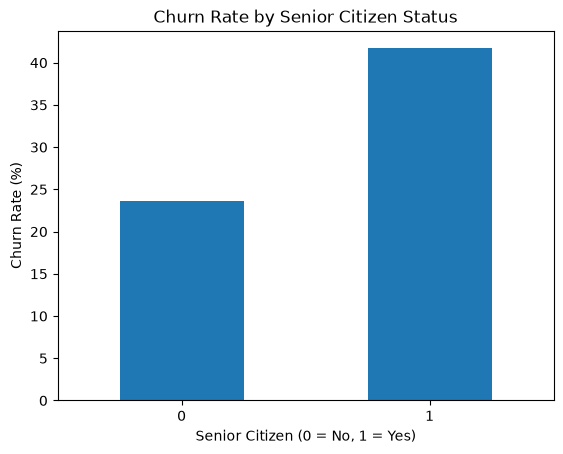

In [42]:
senior_churn["Churn Rate (%)"].plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Churn Rate by Gender

This section compares churn rates between male and female customers.

In [43]:
gender_churn = pd.crosstab(df["gender"], df["Churn"])

gender_churn["Churn Rate (%)"] = (
    gender_churn["Yes"] /
    (gender_churn["Yes"] + gender_churn["No"])
) * 100

print(gender_churn)

Churn     No  Yes  Churn Rate (%)
gender                           
Female  2544  939       26.959518
Male    2619  930       26.204565


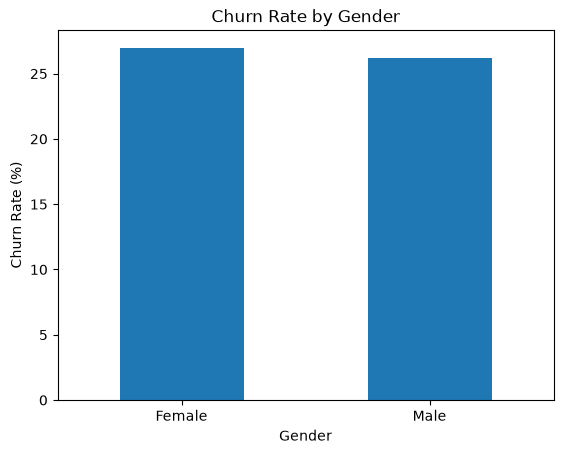

In [44]:
gender_churn["Churn Rate (%)"].plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [45]:
df.drop(columns=["TenureGroup"], inplace=True)
print(df.shape)

(7032, 21)


## Key Insights

- Overall customer churn in the cleaned dataset is approximately 26.58%.
- Month-to-month customers have a churn rate of approximately 42.71%.
- Customers with longer-term contracts show lower churn rates in this dataset.
- Customers with 0–12 months of tenure have the highest churn rate at approximately 47.68%.
- Customers with 61–72 months of tenure have a churn rate of approximately 6.61%.
- Customers who churned had a higher average monthly charge (74.44) compared with customers who stayed (61.31).
- Fiber optic customers have a churn rate of approximately 41.89%.
- Electronic check users have a churn rate of approximately 45.29%.
- Senior citizens have a churn rate of approximately 41.68%, compared with 23.65% for non-senior customers.
- Churn rates for female and male customers are relatively close, at approximately 26.96% and 26.20%.

## Conclusion

This analysis explored customer churn using Python and Pandas. The results show differences in churn across contract type, customer tenure, monthly charges, internet service, payment method, and senior citizen status.

The project helped demonstrate how data cleaning, analysis, and visualization can be used to identify patterns in customer behavior and turn raw data into meaningful insights.

> Note: These findings describe patterns in this dataset and do not necessarily indicate that one factor directly causes customer churn.

In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check the dataset structure

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    


In [3]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

# Check for blank values
print("\nBlank TotalCharges values:")
print((df["TotalCharges"].str.strip() == "").sum())

Missing Values:
Series([], dtype: int64)

Blank TotalCharges values:
11


In [4]:
# Convert TotalCharges from text to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many missing values remain
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Missing TotalCharges: 11


In [5]:
# Remove rows where TotalCharges is missing
df = df.dropna(subset=["TotalCharges"])

print("New Dataset Shape:", df.shape)

New Dataset Shape: (7032, 21)


In [6]:
# Count customers by churn status
churn_counts = df["Churn"].value_counts()

print("Customer Churn:")
print(churn_counts)

# Calculate churn percentage
churn_rate = (df["Churn"].value_counts(normalize=True) * 100).round(2)

print("\nChurn Rate (%):")
print(churn_rate)

Customer Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Rate (%):
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


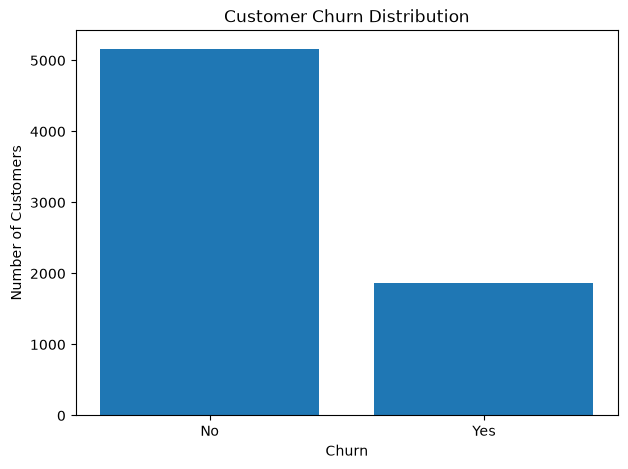

In [7]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [8]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

print(contract_churn)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48


In [9]:
contract_churn_rate = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
).round(2)

print(contract_churn_rate)

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


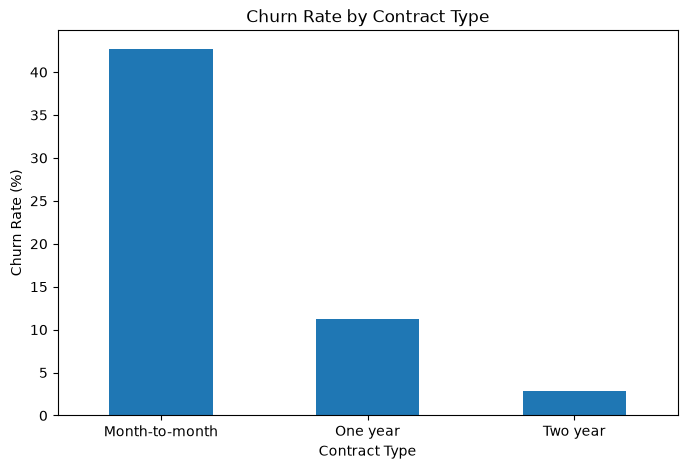

In [10]:
contract_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [11]:
# Create customer tenure groups

bins = [0, 12, 24, 48, 60, 72]
labels = ["0-12 months", "13-24 months", "25-48 months", "49-60 months", "61-72 months"]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate churn rate for each tenure group
tenure_churn = (
    pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index") * 100
).round(2)

print(tenure_churn)

Churn            No    Yes
TenureGroup               
0-12 months   52.32  47.68
13-24 months  71.29  28.71
25-48 months  79.61  20.39
49-60 months  85.58  14.42
61-72 months  93.39   6.61


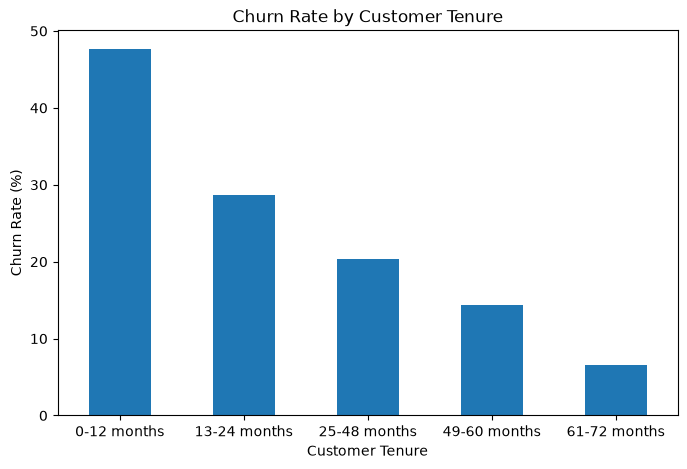

In [12]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [13]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean().round(2)

print("Average Monthly Charges by Churn Status:")
print(monthly_charges_churn)

Average Monthly Charges by Churn Status:
Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


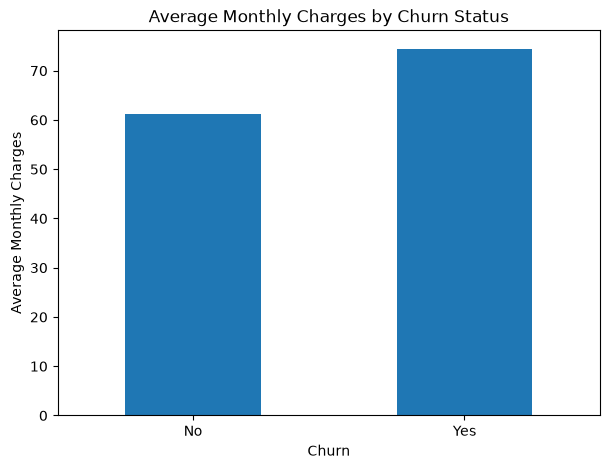

In [14]:
monthly_charges_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.show()

In [15]:
internet_churn = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
).round(2)

print("Churn Rate by Internet Service:")
print(internet_churn)

Churn Rate by Internet Service:
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


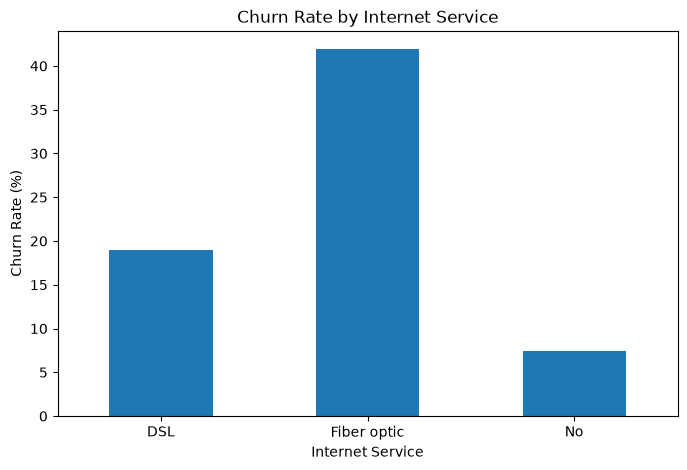

In [16]:
internet_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [17]:
payment_churn = (
    pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
).round(2)

print("Churn Rate by Payment Method:")
print(payment_churn)

Churn Rate by Payment Method:
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.27  16.73
Credit card (automatic)    84.75  15.25
Electronic check           54.71  45.29
Mailed check               80.80  19.20


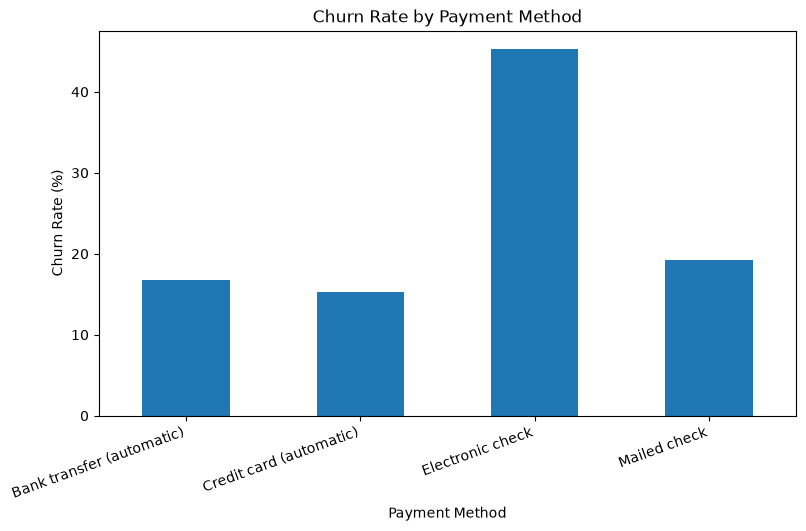

In [18]:
payment_churn["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.show()

In [20]:
# Churn rate by gender
gender_churn = (
    pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100
).round(2)

print("Churn Rate by Gender:")
print(gender_churn)

# Churn rate by senior citizen status
senior_churn = (
    pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
).round(2)

print("\nChurn Rate by Senior Citizen Status:")
print(senior_churn)

Churn Rate by Gender:
Churn      No    Yes
gender              
Female  73.04  26.96
Male    73.80  26.20

Churn Rate by Senior Citizen Status:
Churn             No    Yes
SeniorCitizen              
0              76.35  23.65
1              58.32  41.68


In [21]:
# Remove the temporary analysis column
df.drop(columns=["TenureGroup"], inplace=True)

print(df.shape)

(7032, 21)
